# Reto 3 - Colores

## 1. Lectura de la imagen a color

Se carga una imagen a color utilizando OpenCV y se inspeccionan sus dimensiones mediante el atributo `shape`.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

ruta_imagen = "imagenes/imagen_colores.jpg"

imagen = cv2.imread(ruta_imagen)

if imagen is None:
    print("Error: no se pudo cargar la imagen.")
else:
    print("Imagen cargada correctamente.")
    print("Shape de la imagen:", imagen.shape)

Imagen cargada correctamente.
Shape de la imagen: (455, 728, 3)


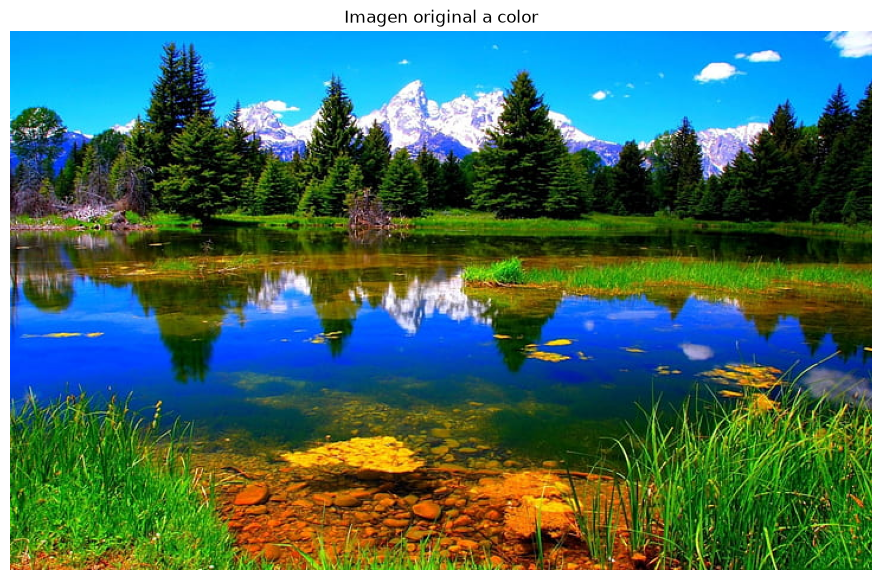

In [2]:
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(imagen_rgb)
plt.title("Imagen original a color")
plt.axis("off")
plt.show()

## 2. Definición de regiones de interés

Se seleccionan cinco regiones aproximadamente homogéneas de colores diferentes y una sexta región heterogénea que contiene mezcla de varios colores.

In [3]:
# Regiones homogéneas
regiones = {
    "Cielo azul": (60, 25, 100, 65),
    "Nieve blanca": (318, 58, 350, 88),
    "Verde oscuro": (438, 92, 470, 124),
    "Verde claro": (30, 355, 62, 387),
    "Naranja / rocas": (438, 385, 470, 417),

    # Región no homogénea
    "Mezcla de colores": (285, 330, 345, 390)
}

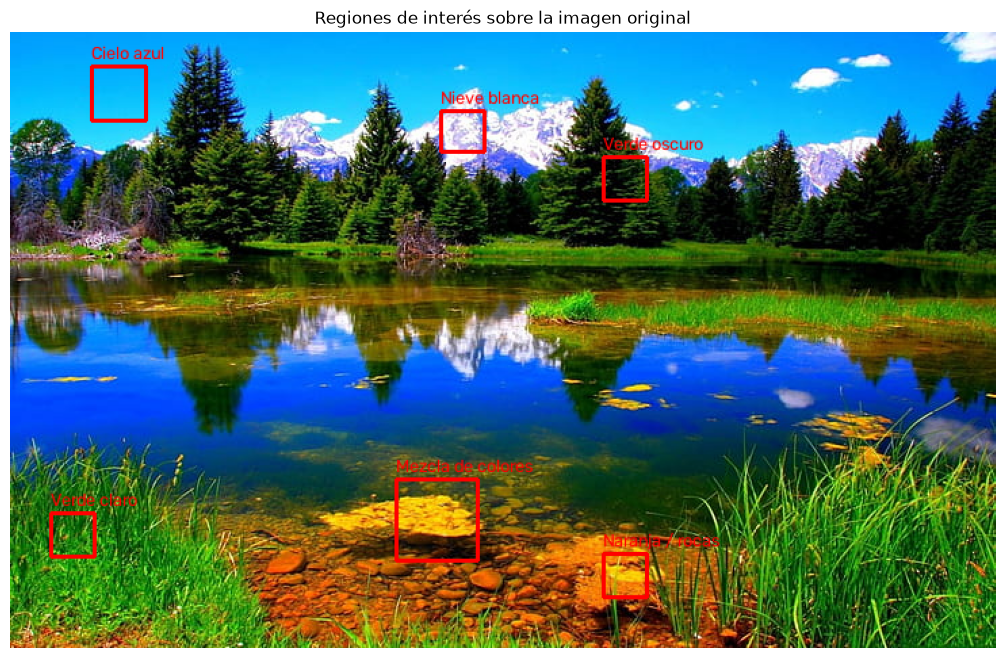

In [4]:
imagen_dibujada = imagen_rgb.copy()

for nombre, (x1, y1, x2, y2) in regiones.items():
    cv2.rectangle(imagen_dibujada, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(
        imagen_dibujada,
        nombre,
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (255, 0, 0),
        1,
        cv2.LINE_AA
    )

plt.figure(figsize=(14, 8))
plt.imshow(imagen_dibujada)
plt.title("Regiones de interés sobre la imagen original")
plt.axis("off")
plt.show()

## 3. Estadísticas de las regiones de interés

Para cada región se calcula la media y la desviación estándar de los tres canales de color. Debido a que la imagen fue leída mediante OpenCV, los canales están organizados en el orden BGR: azul, verde y rojo.

In [5]:
resultados = {}

for nombre, (x1, y1, x2, y2) in regiones.items():

    # Extraer región desde la imagen original BGR
    roi = imagen[y1:y2, x1:x2]

    # Media de cada canal
    media_b = np.mean(roi[:, :, 0])
    media_g = np.mean(roi[:, :, 1])
    media_r = np.mean(roi[:, :, 2])

    # Desviación estándar de cada canal
    std_b = np.std(roi[:, :, 0])
    std_g = np.std(roi[:, :, 1])
    std_r = np.std(roi[:, :, 2])

    resultados[nombre] = {
        "Media B": media_b,
        "Media G": media_g,
        "Media R": media_r,
        "Std B": std_b,
        "Std G": std_g,
        "Std R": std_r
    }

In [6]:
for nombre, datos in resultados.items():

    print("\nREGIÓN:", nombre)

    print("Media:")
    print("  B =", round(datos["Media B"], 2))
    print("  G =", round(datos["Media G"], 2))
    print("  R =", round(datos["Media R"], 2))

    print("Desviación estándar:")
    print("  B =", round(datos["Std B"], 2))
    print("  G =", round(datos["Std G"], 2))
    print("  R =", round(datos["Std R"], 2))


REGIÓN: Cielo azul
Media:
  B = 253.78
  G = 190.02
  R = 10.49
Desviación estándar:
  B = 0.94
  G = 10.11
  R = 7.91

REGIÓN: Nieve blanca
Media:
  B = 239.28
  G = 212.26
  R = 213.07
Desviación estándar:
  B = 16.79
  G = 37.34
  R = 43.32

REGIÓN: Verde oscuro
Media:
  B = 15.94
  G = 35.3
  R = 21.39
Desviación estándar:
  B = 24.95
  G = 34.25
  R = 26.82

REGIÓN: Verde claro
Media:
  B = 19.44
  G = 119.92
  R = 41.53
Desviación estándar:
  B = 22.65
  G = 37.16
  R = 36.76

REGIÓN: Naranja / rocas
Media:
  B = 14.61
  G = 140.5
  R = 224.48
Desviación estándar:
  B = 14.84
  G = 44.42
  R = 36.6

REGIÓN: Mezcla de colores
Media:
  B = 16.13
  G = 105.86
  R = 140.09
Desviación estándar:
  B = 15.09
  G = 68.93
  R = 87.31


## 4. Análisis de resultados

Los resultados obtenidos muestran una correspondencia clara entre los valores medios de los canales BGR y los colores observados visualmente en cada región.

En la región correspondiente al cielo azul, el canal azul presentó la media más alta (253.78), mientras que el canal rojo obtuvo un valor muy bajo (10.49). Esto coincide con la tonalidad azul intensa observada en la imagen. Además, la baja desviación estándar del canal azul (0.94) indica que esta región presenta una alta homogeneidad.

En la región de nieve, los tres canales presentan valores elevados (B = 239.28, G = 212.26 y R = 213.07), lo cual es característico de colores cercanos al blanco. Las desviaciones estándar son mayores que en el cielo debido a la presencia de sombras, textura y variaciones de iluminación sobre la montaña.

En la región verde oscura, los tres canales poseen valores relativamente bajos, pero el canal verde es el mayor (35.30), lo que corresponde con la apariencia verde oscura de los árboles. En la región verde clara, el canal verde alcanza un valor medio mucho mayor (119.92), evidenciando una mayor intensidad de este componente y explicando su apariencia más luminosa.

En la región naranja correspondiente a las rocas, el canal rojo presenta la mayor media (224.48), seguido por el canal verde (140.50), mientras que el azul tiene una presencia muy baja (14.61). Esta combinación de componentes produce visualmente una tonalidad naranja.

Finalmente, la región con mezcla de colores presenta desviaciones estándar elevadas, especialmente en los canales verde (68.93) y rojo (87.31). Esto indica una mayor dispersión de los valores de los píxeles debido a la presencia de diferentes colores dentro de una misma región. En contraste, las regiones más homogéneas presentan generalmente una menor variabilidad.

## 5. Conclusiones

1. Los valores medios de los canales BGR permiten relacionar cuantitativamente los píxeles de una imagen con el color que se observa visualmente.

2. Un canal con una media elevada suele tener una participación importante en el color de la región. Por ejemplo, el canal azul fue dominante en el cielo, el verde en la vegetación y el rojo en las rocas de tonalidad naranja.

3. Los colores claros, como la nieve, presentan valores altos simultáneamente en los tres canales, mientras que las regiones oscuras presentan valores más bajos.

4. La desviación estándar permite evaluar la homogeneidad de una región. Valores pequeños indican que los píxeles son similares entre sí, mientras que valores elevados indican una mayor diversidad de intensidades.

5. La región seleccionada con mezcla de colores presentó una variabilidad considerablemente mayor en algunos canales, especialmente verde y rojo, confirmando que se trata de una región menos homogénea.

6. El análisis de regiones de interés permite estudiar de forma localizada la información de color presente en una imagen digital.

In [7]:
import pandas as pd

tabla_resultados = pd.DataFrame(resultados).T

tabla_resultados = tabla_resultados.round(2)

tabla_resultados

,Media B,Media G,Media R,Std B,Std G,Std R
Cielo azul,253.78,190.02,10.49,0.94,10.11,7.91
Nieve blanca,239.28,212.26,213.07,16.79,37.34,43.32
Verde oscuro,15.94,35.30,21.39,24.95,34.25,26.82
Verde claro,19.44,119.92,41.53,22.65,37.16,36.76
Naranja / rocas,14.61,140.50,224.48,14.84,44.42,36.60
Mezcla de colores,16.13,105.86,140.09,15.09,68.93,87.31


## 6. Visualización individual de las regiones

Se muestran por separado las seis regiones de interés seleccionadas para comparar visualmente su homogeneidad y variedad de colores.

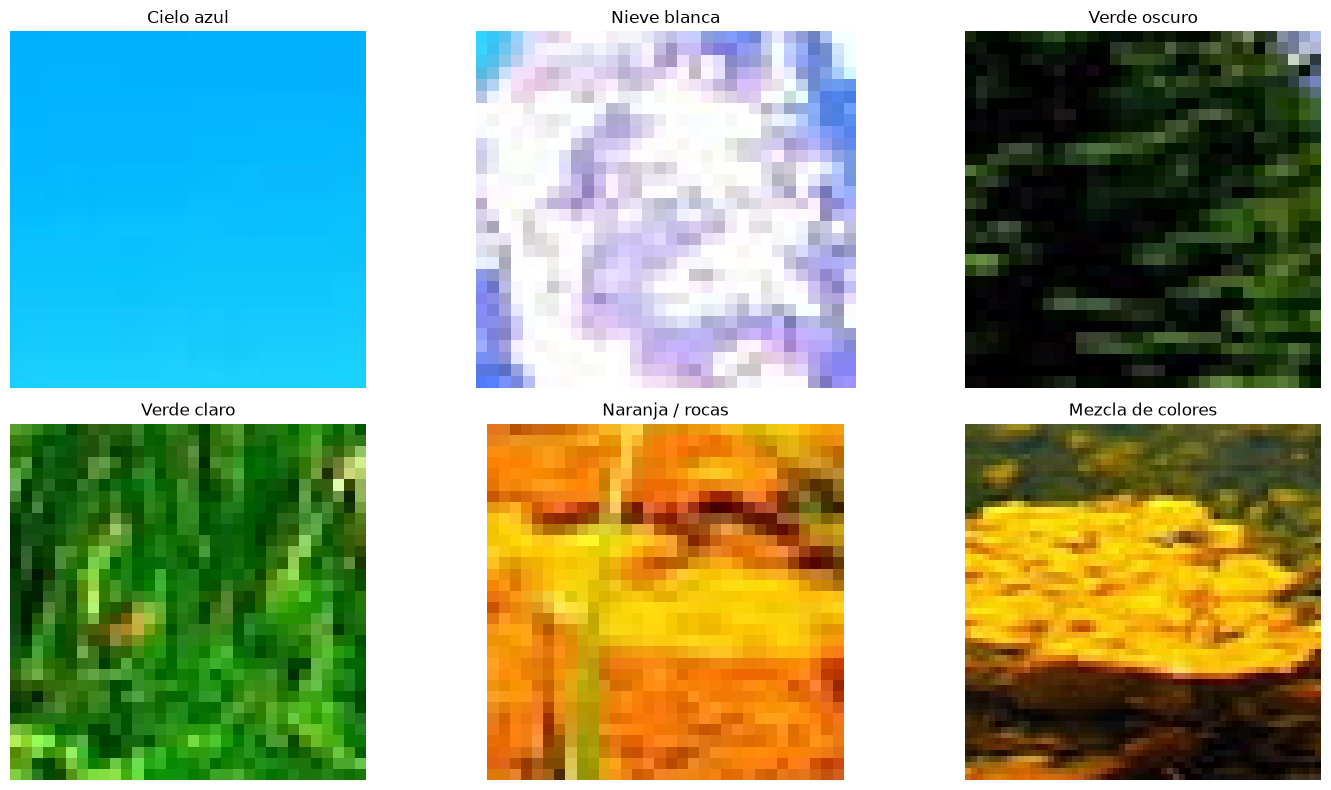

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (nombre, (x1, y1, x2, y2)) in zip(axes.flatten(), regiones.items()):

    roi_rgb = imagen_rgb[y1:y2, x1:x2]

    ax.imshow(roi_rgb)
    ax.set_title(nombre)
    ax.axis("off")

plt.tight_layout()
plt.show()